# Dinâmicas de Género e o "Efeito Bolha"

**Objetivo:** Desconstruir o catálogo para entender quais os géneros narrativos que dominam o mercado, tanto em volume de produção como em avaliação do público, e testar a hipótese do "Efeito Bolha" em géneros de nicho.

### Perguntas de Negócio
1. **O Domínio da Produção:** Quais são os géneros mais produzidos/catalogados em cada mídia (O que a indústria mais entrega)?
   
2. **O Favoritismo do Público (Notas por Gênero):** Existe algum gênero que receba sistematicamente notas mais altas?
   
3. **O "Efeito Bolha" em Ação:** Géneros de nicho altamente segmentados (como Ficção Científica dura ou Fantasia Épica) apresentam anomalias nas suas notas devido a uma base de fãs extremamente fiel (Efeito Bolha)?

In [1]:
# Configuração do Jupyter (Autoreload)
%load_ext autoreload
%autoreload 2

# Configuração de Caminho (Path Setup)
import sys
import os

# Adiciona a pasta raiz do projeto (..) ao sistema para liberar os imports locais
sys.path.append(os.path.abspath(os.path.join('..', '..')))

# Importação de Bibliotecas e Módulos
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

# Módulos customizados da pasta src/
import src.io.data_loader as dl
import src.io.data_save as ds
import src.io.db_client as dbc
import src.view.tables as tb
import src.view.plots as graf

---
## Caminho central para a base de dados relacional


In [2]:
caminho_banco = '../../data/processed/unified_media_catalog.db'

---
## Definindo dataframe padrão do notebook

In [3]:
query = """
        SELECT
            g.media_type,
            g.genres,
            COUNT(c.id) as volume_obras,
            ROUND(AVG(c.global_score), 2) AS Nota_Media_Genero
        FROM unified_media_genres as g
        INNER JOIN unified_media_catalog as c
            ON c.id = g.id
        WHERE c.global_score > 0
        GROUP BY g.media_type, g.genres
        HAVING volume_obras >= 500
        ORDER BY Nota_Media_Genero DESC, volume_obras DESC;
    """

df_genre_dynamics = dbc.execute_query(
    caminho_banco,
    alvo=query,
    eh_query=True
)


Dados carregados via SQL! Formato: (77, 4)


---
## O Domínio da Produção

In [4]:
# Top 10 Filmes
display(
    tb.estilizar_tabela(
        df=df_genre_dynamics[
            df_genre_dynamics['media_type'] == 'Movie'
        ].sort_values('volume_obras', ascending=True),
        colunas_selecionadas=['media_type', 'genres', 'volume_obras'],
        qtd_linhas=10,
        caption='Top 10 Géneros mais frequentes no Cinema'
    )
    .bar(subset=['volume_obras'], color='#4C72B0')
)

# Top 10 Livros
display(
    tb.estilizar_tabela(
        df=df_genre_dynamics[
            df_genre_dynamics['media_type'] == 'Book'
        ].sort_values('volume_obras', ascending=True),
        colunas_selecionadas=['media_type', 'genres', 'volume_obras'],
        qtd_linhas=10,
        caption='Top 10 Géneros mais frequentes na Literatura'
    )
    .bar(subset=['volume_obras'], color='#55A868')
)

,media_type,genres,volume_obras
74,Movie,TV Movie,713
73,Movie,Western,1039
70,Movie,Gênero Não Identificado,1399
60,Movie,War,1410
58,Movie,History,1485
59,Movie,Music,1612
68,Movie,Foreign,1634
57,Movie,Animation,2061
67,Movie,Fantasy,2543
64,Movie,Mystery,2692


,media_type,genres,volume_obras
16,Book,"Mystery,Detective",519
2,Book,Spirituality,529
24,Book,"Literature,19th Century",548
30,Book,"Fantasy,Paranormal",577
27,Book,"Humor,Comedy",590
55,Book,"Womens Fiction,Chick Lit",612
14,Book,"Fantasy,Magic",617
51,Book,Gênero Não Identificado,649
15,Book,War,658
18,Book,"Writing,Essays",679


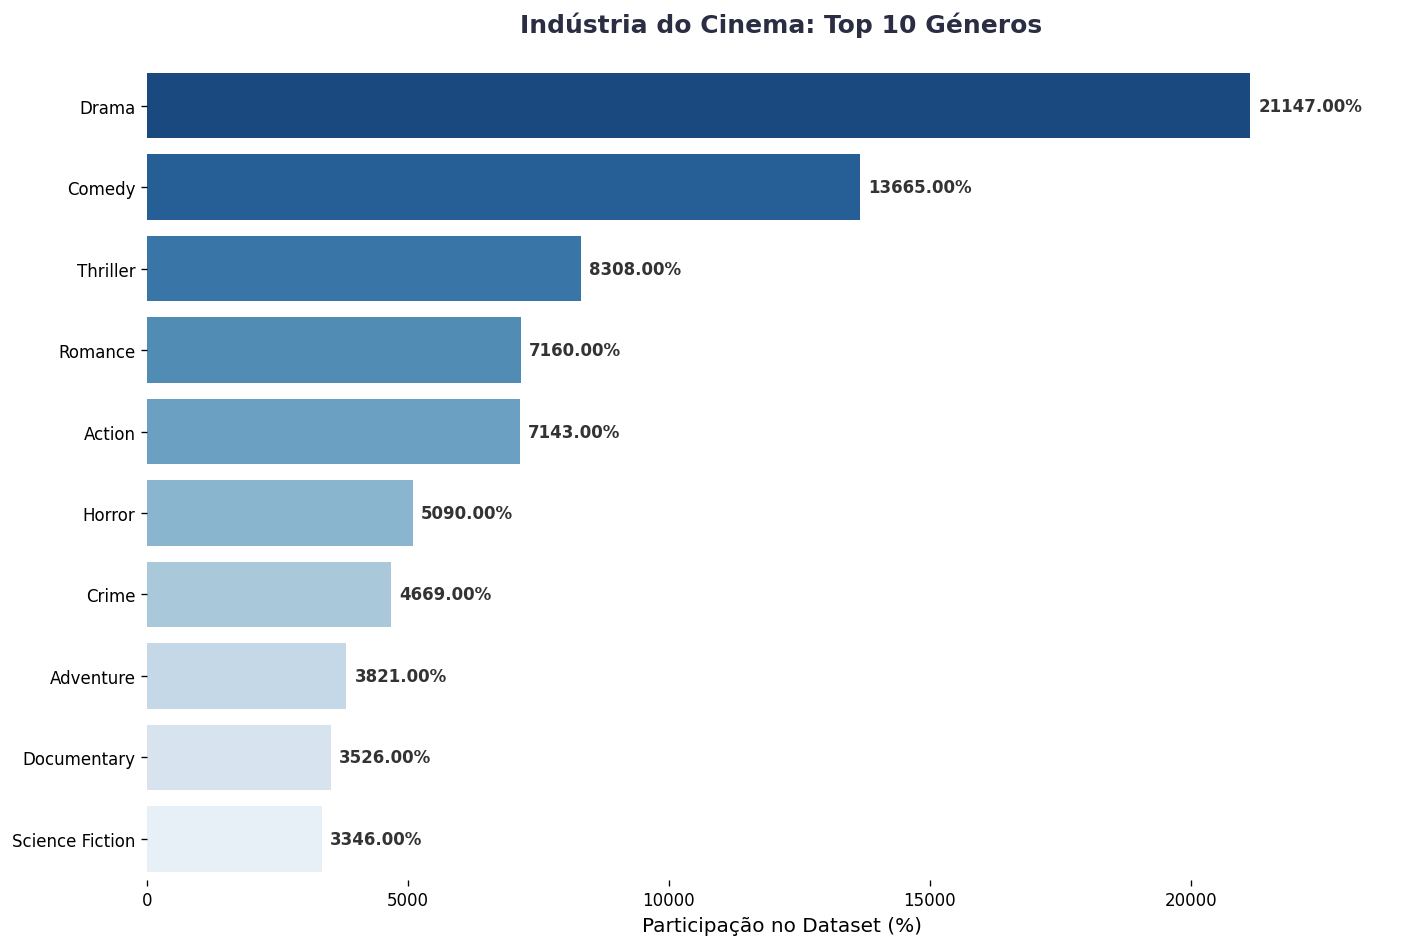

In [5]:
graf.grafico_top_categorias(
    df=df_genre_dynamics[
        df_genre_dynamics['media_type'] == 'Movie'
    ].sort_values('volume_obras', ascending=False),
    nome_coluna='genres',
    coluna_frequencia='volume_obras',
    top_n=10,
    titulo='Indústria do Cinema: Top 10 Géneros',
    palette='Blues_r'
)

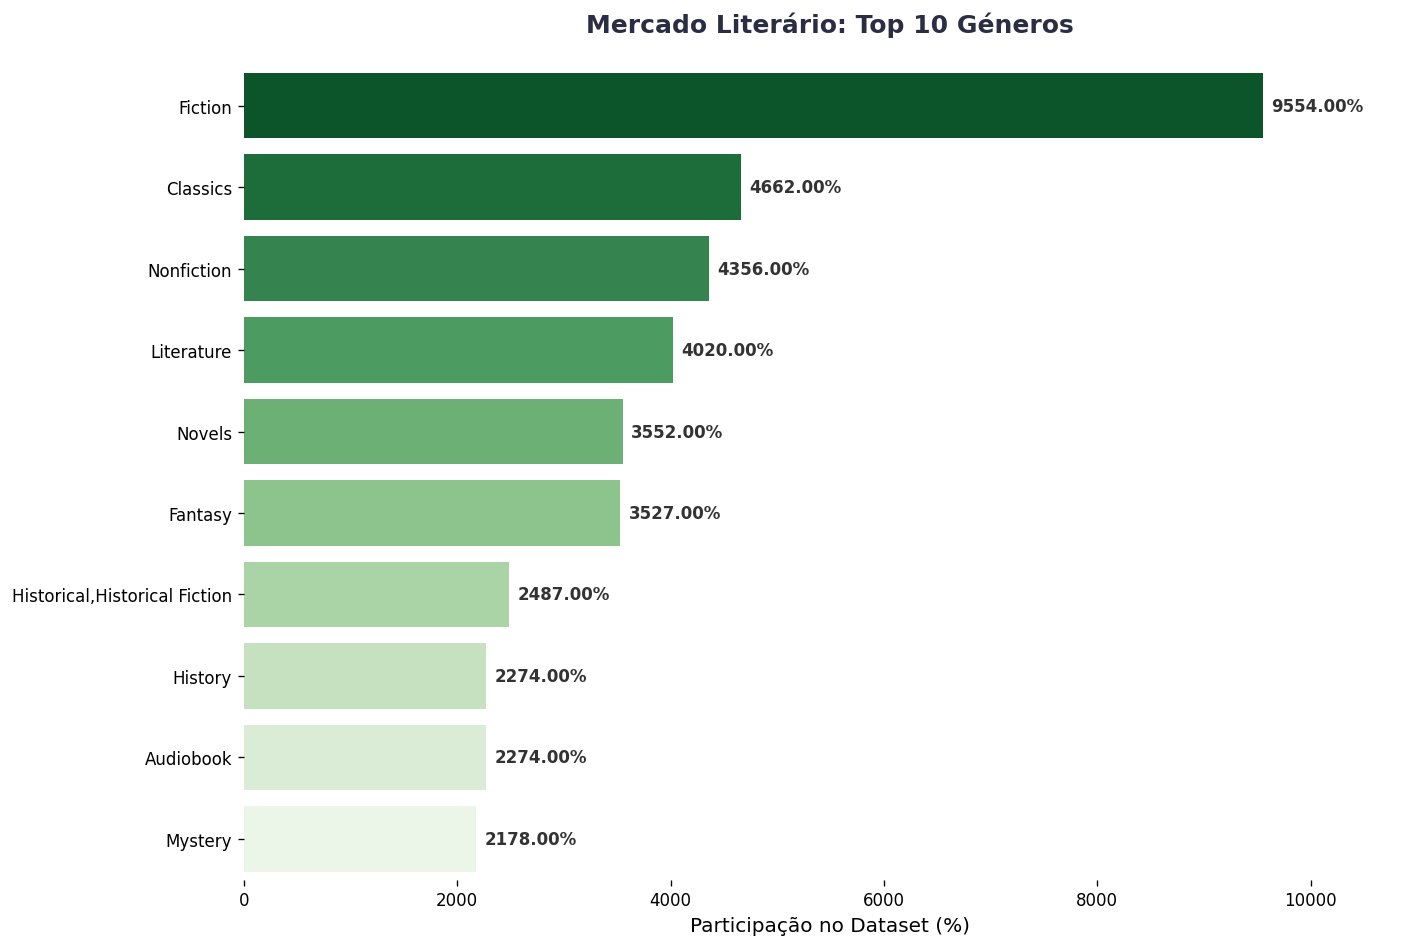

In [6]:
graf.grafico_top_categorias(
    df=df_genre_dynamics[
        df_genre_dynamics['media_type'] == 'Book'
    ].sort_values('volume_obras', ascending=False),
    nome_coluna='genres',
    coluna_frequencia='volume_obras',
    top_n=10,
    titulo='Mercado Literário: Top 10 Géneros',
    palette='Greens_r'
)

### O MARKET SHARE: COMPARAÇÃO PROPORCIONAL DE GÉNEROS COMUNS

In [7]:
# Calculo do total de obras por mídia para descobrirmos a percentagem
total_por_midia = df_genre_dynamics.groupby('media_type')['volume_obras'].sum()

# Ciração da coluna de percentagem (Market Share)
df_pct = df_genre_dynamics.copy()
df_pct['frequencia_pct'] = df_pct.apply(
    lambda row: (row['volume_obras'] / total_por_midia[row['media_type']]) * 100, 
    axis=1
)

# Comparação de géneros em comum (Pivot Table)
df_pivot = df_pct.pivot(
    index='genres', 
    columns='media_type', 
    values='frequencia_pct'
)

df_comuns = df_pivot.dropna().copy()

df_comuns['relevancia_total'] = df_comuns['Book'] + df_comuns['Movie']
df_top_comuns = df_comuns.sort_values('relevancia_total', ascending=False).head(10)

# Remover a coluna de soma e voltar ao formato normal para o gráfico
df_top_comuns = df_top_comuns.drop(columns=['relevancia_total']).reset_index()
df_plot_comuns = df_top_comuns.melt(id_vars='genres', var_name='media_type', value_name='pct')


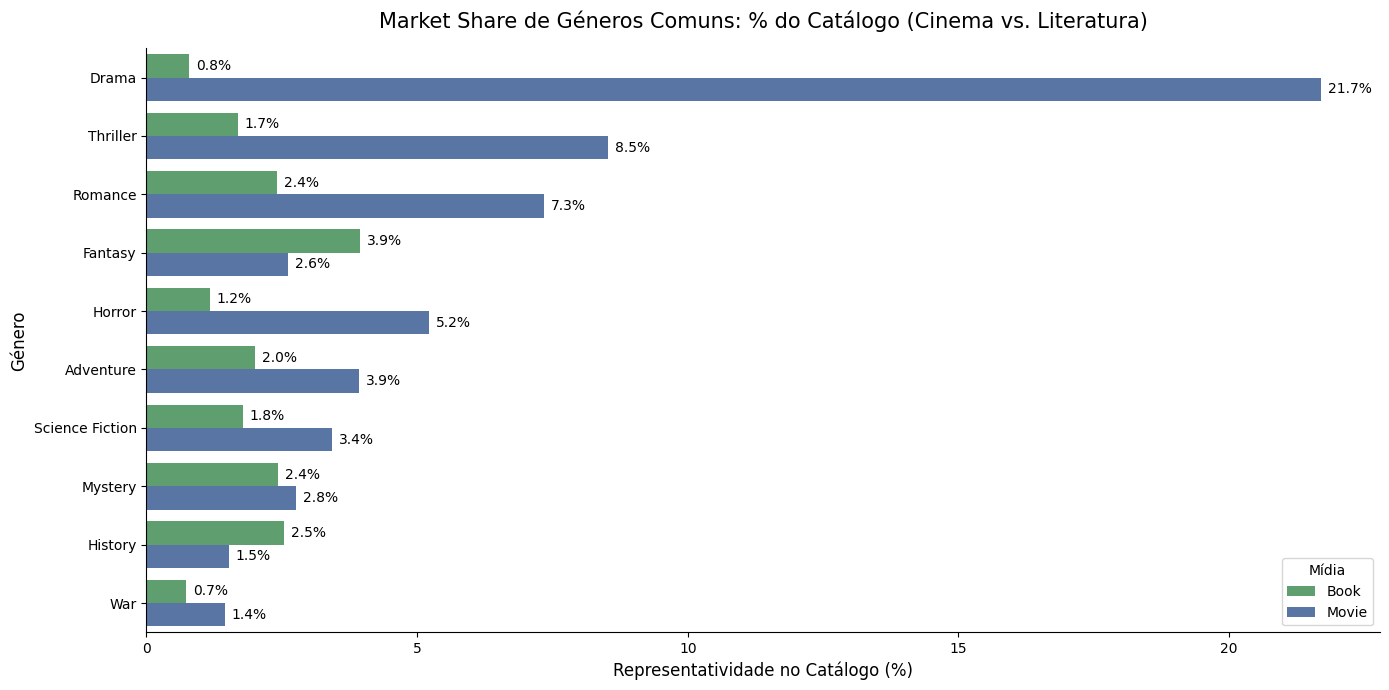

In [8]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df_plot_comuns, 
    x='pct', 
    y='genres', 
    hue='media_type', 
    palette={'Movie': '#4C72B0', 'Book': '#55A868'}
)

plt.title('Market Share de Géneros Comuns: % do Catálogo (Cinema vs. Literatura)', fontsize=15, pad=15)
plt.xlabel('Representatividade no Catálogo (%)', fontsize=12)
plt.ylabel('Género', fontsize=12)
plt.legend(title='Mídia')

# Adicionar os valores exatos no final de cada barra
for ax in plt.gca().containers:
    plt.gca().bar_label(ax, fmt='%.1f%%', padding=5, fontsize=10)

sns.despine()
plt.tight_layout()
plt.show()

---
## O Favoritismo do Público: Nota Por Gênero

In [9]:
display(
    tb.estilizar_tabela(
        df=df_genre_dynamics[
            df_genre_dynamics['media_type']=='Movie'
        ],
        qtd_linhas=10,
        caption='Gêneros Cinematográficos com Maiores Notas Médias'
    )   
    .bar(subset=['Nota_Media_Genero'], color='#4C72B0')
    .background_gradient(subset=['volume_obras'], cmap='Purples')
    .format({'Nota_Media_Genero': '{:.2f}'})
)

display(
    tb.estilizar_tabela(
        df=df_genre_dynamics[
            df_genre_dynamics['media_type']=='Book'
        ],
        qtd_linhas=10,
        caption='Gêneros Literários com Maiores Notas Médias'
    )   
    .bar(subset=['Nota_Media_Genero'], color='#55A868')
    .background_gradient(subset=['volume_obras'], cmap='Purples')
    .format({'Nota_Media_Genero': '{:.2f}'})
)

,media_type,genres,volume_obras,Nota_Media_Genero
56,Movie,Documentary,3526,67.47
57,Movie,Animation,2061,66.22
58,Movie,History,1485,66.00
59,Movie,Music,1612,65.11
60,Movie,War,1410,64.75
61,Movie,Drama,21147,63.65
62,Movie,Crime,4669,63.28
63,Movie,Romance,7160,62.64
64,Movie,Mystery,2692,62.03
65,Movie,Comedy,13665,61.95


,media_type,genres,volume_obras,Nota_Media_Genero
0,Book,"Sequential Art,Graphic Novels",705,75.89
1,Book,"Sequential Art,Comics",693,75.75
2,Book,Spirituality,529,75.45
3,Book,Poetry,848,75.26
4,Book,Reference,887,75.21
5,Book,Childrens,1542,75.05
6,Book,Science,717,74.95
7,Book,Philosophy,1725,74.94
8,Book,"Childrens,Middle Grade",780,74.87
9,Book,Religion,883,74.85


---
## O "Efeito Bolha": Nicho VS. Mercado de Massas
* Como o Volume de Obras por Gênero Afeta as Notas Média? 

#### Funções de Relatório e Plotagem de Gráfico

In [10]:
# Função responsavel por gerar df e relatorio de Notas Médias dos Gêneros Por Volune 
def favoritismo_por_volume(df):
    display(
        tb.estilizar_tabela(
            df=df[
                df['media_type']=='Movie'
            ],
            qtd_linhas=10,
            caption='Gêneros Cinematográficos Mais Produzidos e Suas Notas Médias'
        )   
        .bar(subset=['Nota_Media_Genero'], color='#4C72B0')
        .background_gradient(subset=['volume_obras'], cmap='Purples')
        .format({'Nota_Media_Genero': '{:.2f}'})
    )

    display(
        tb.estilizar_tabela(
            df=df[
                df['media_type']=='Book'
            ],
            qtd_linhas=10,
            caption='Gêneros Literários Mais Publicados e Suas Notas Médias'
        )   
        .bar(subset=['Nota_Media_Genero'], color='#55A868')
        .background_gradient(subset=['volume_obras'], cmap='Purples')
        .format({'Nota_Media_Genero': '{:.2f}'})
    )

In [11]:
def grafico_nota_media_genero(df, palette, titulo):
    plt.figure(figsize=(16, 8), dpi=150)

    # Gráfico Cinema
    ax = sns.barplot(
        data=df,
        x='Nota_Media_Genero',
        y='genres', 
        hue='genres',
        palette=palette,
        legend=False
    )

    ax.set_title(titulo, fontsize=14, pad=15)
    ax.set_xlabel('Nota Média Global (0-100)', fontsize=12)
    ax.set_ylabel('Gênero', fontsize=12)
    ax.set_xlim(0, 100)

    labels = [
        f"{nota:.1f} (Vol: {vol:,})" 
        for nota, vol in zip(df['Nota_Media_Genero'], df['volume_obras'])
    ]

    for container, label in zip(ax.containers, labels):
        ax.bar_label(container, labels=[label], padding=5, fontsize=10)

    sns.despine()
    plt.tight_layout()
    plt.show()

In [12]:
midia = ['Movie', 'Book']
cor = ['Blues_r', 'Greens_r']

def tipo_titulo(classificacao, midia):
    match midia:
        case 'Movie':
            return f'Cinema: Notas dos 10 Gêneros {classificacao} Produzidos'
        case 'Book':
            return f'Literatura: Notas dos 10 Gêneros {classificacao} Publicados'  
        case _:
            print('Mídia não registrada!')


#### Análise do Maior Volume de Obras

In [13]:
# Notas Por Gêneros Com Maior Volume de Obras
df_bolha_desc = df_genre_dynamics.sort_values('volume_obras', ascending=False)

favoritismo_por_volume(df_bolha_desc)

,media_type,genres,volume_obras,Nota_Media_Genero
61,Movie,Drama,21147,63.65
65,Movie,Comedy,13665,61.95
72,Movie,Thriller,8308,60.05
63,Movie,Romance,7160,62.64
71,Movie,Action,7143,60.06
76,Movie,Horror,5090,56.09
62,Movie,Crime,4669,63.28
69,Movie,Adventure,3821,61.46
56,Movie,Documentary,3526,67.47
75,Movie,Science Fiction,3346,57.78


,media_type,genres,volume_obras,Nota_Media_Genero
33,Book,Fiction,9554,73.66
12,Book,Classics,4662,74.80
19,Book,Nonfiction,4356,74.55
32,Book,Literature,4020,73.78
47,Book,Novels,3552,72.98
17,Book,Fantasy,3527,74.65
38,Book,"Historical,Historical Fiction",2487,73.51
20,Book,History,2274,74.55
28,Book,Audiobook,2274,73.96
44,Book,Mystery,2178,73.15


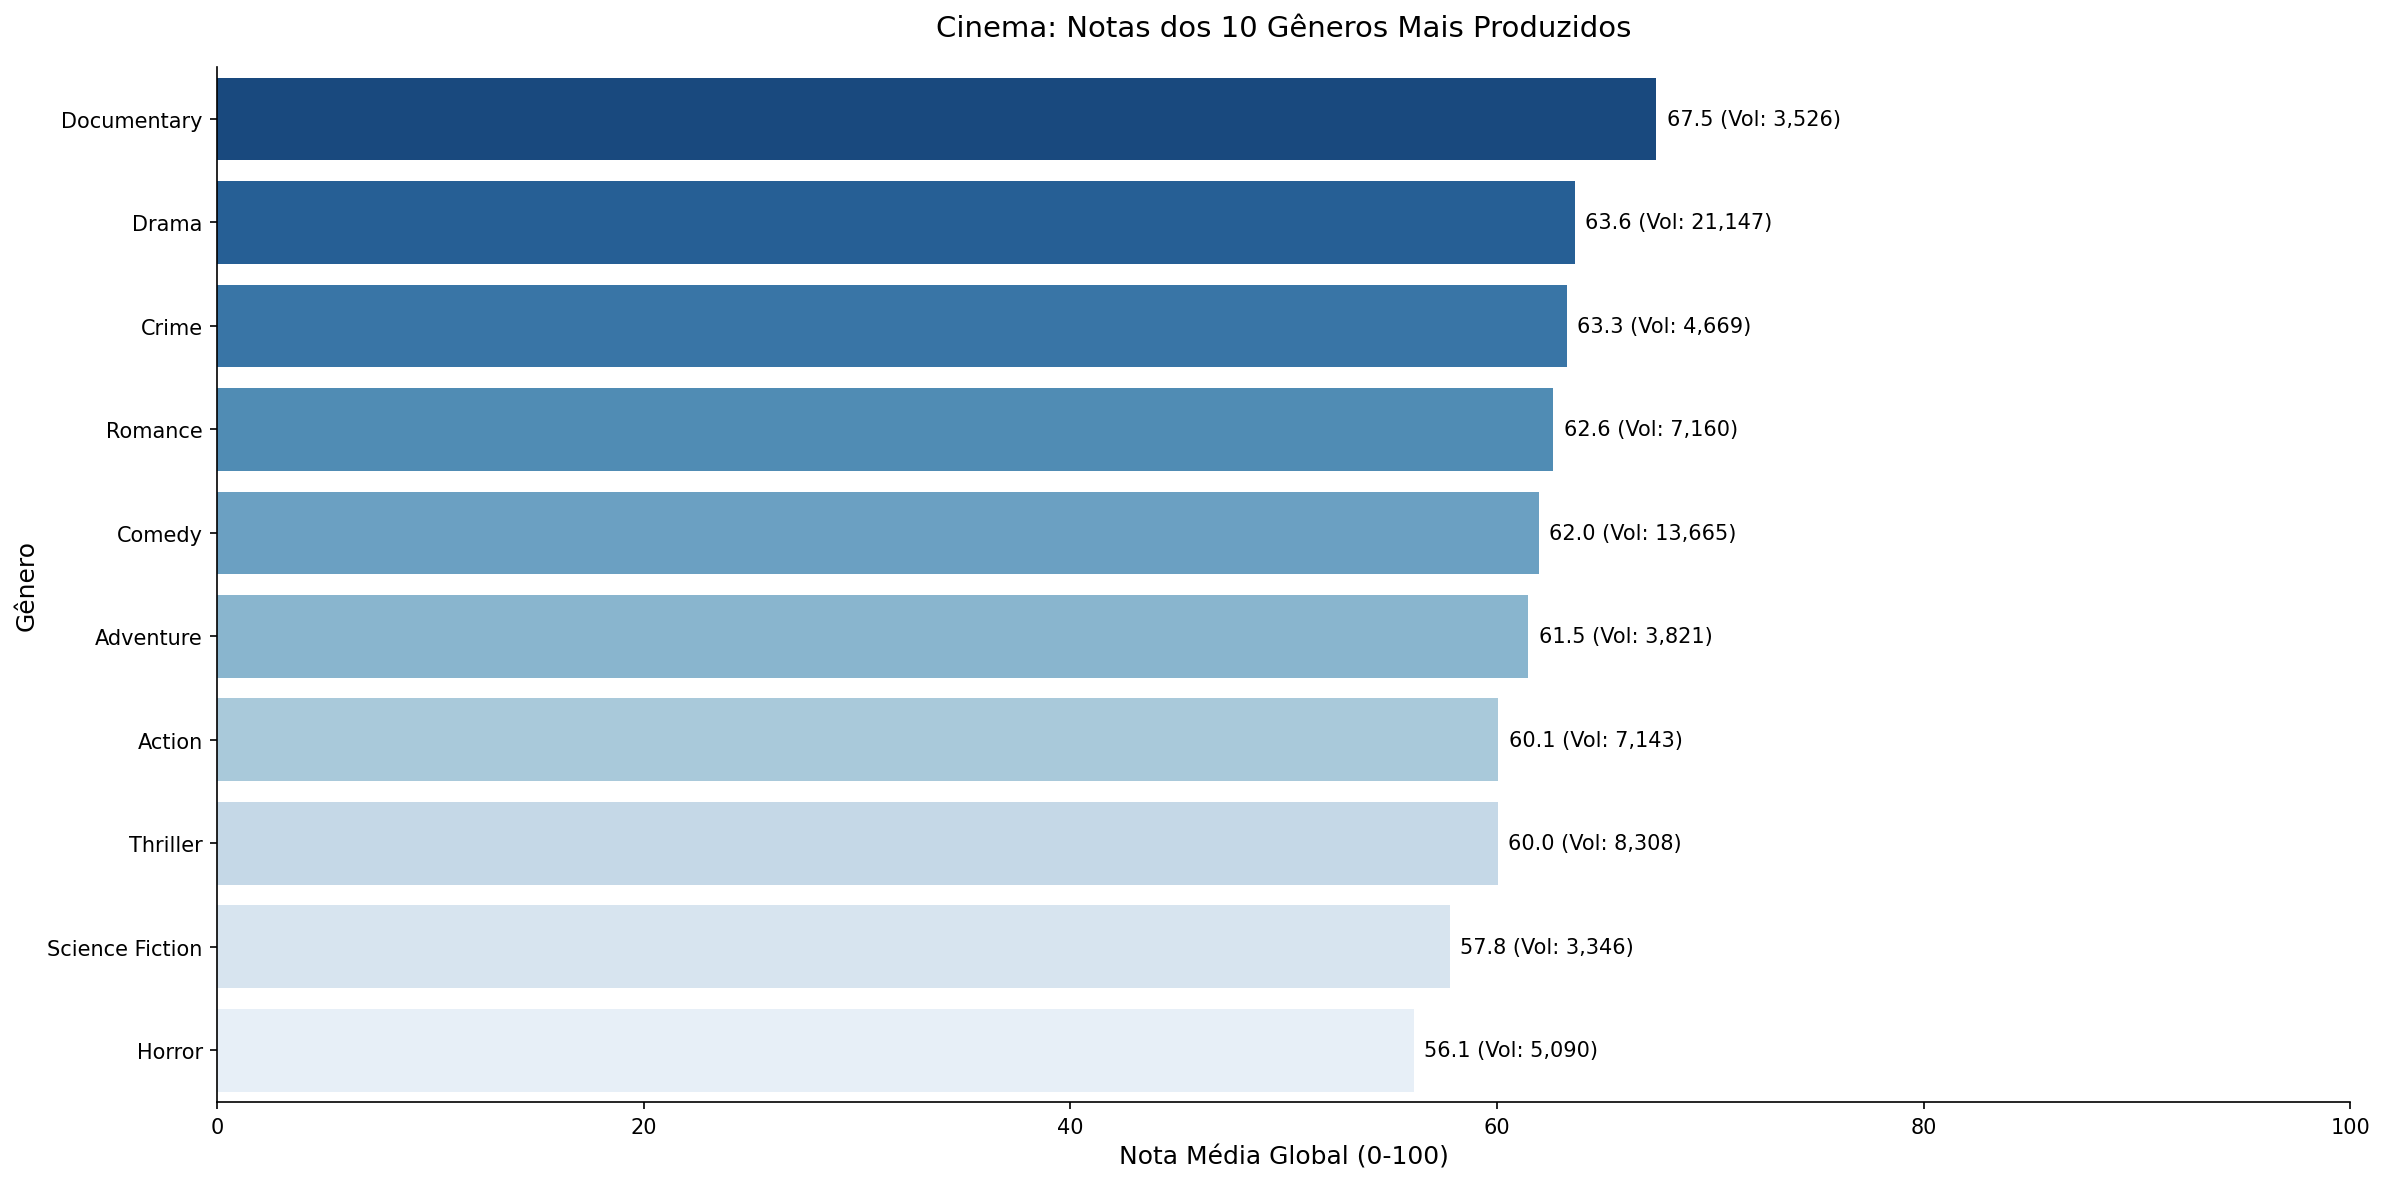

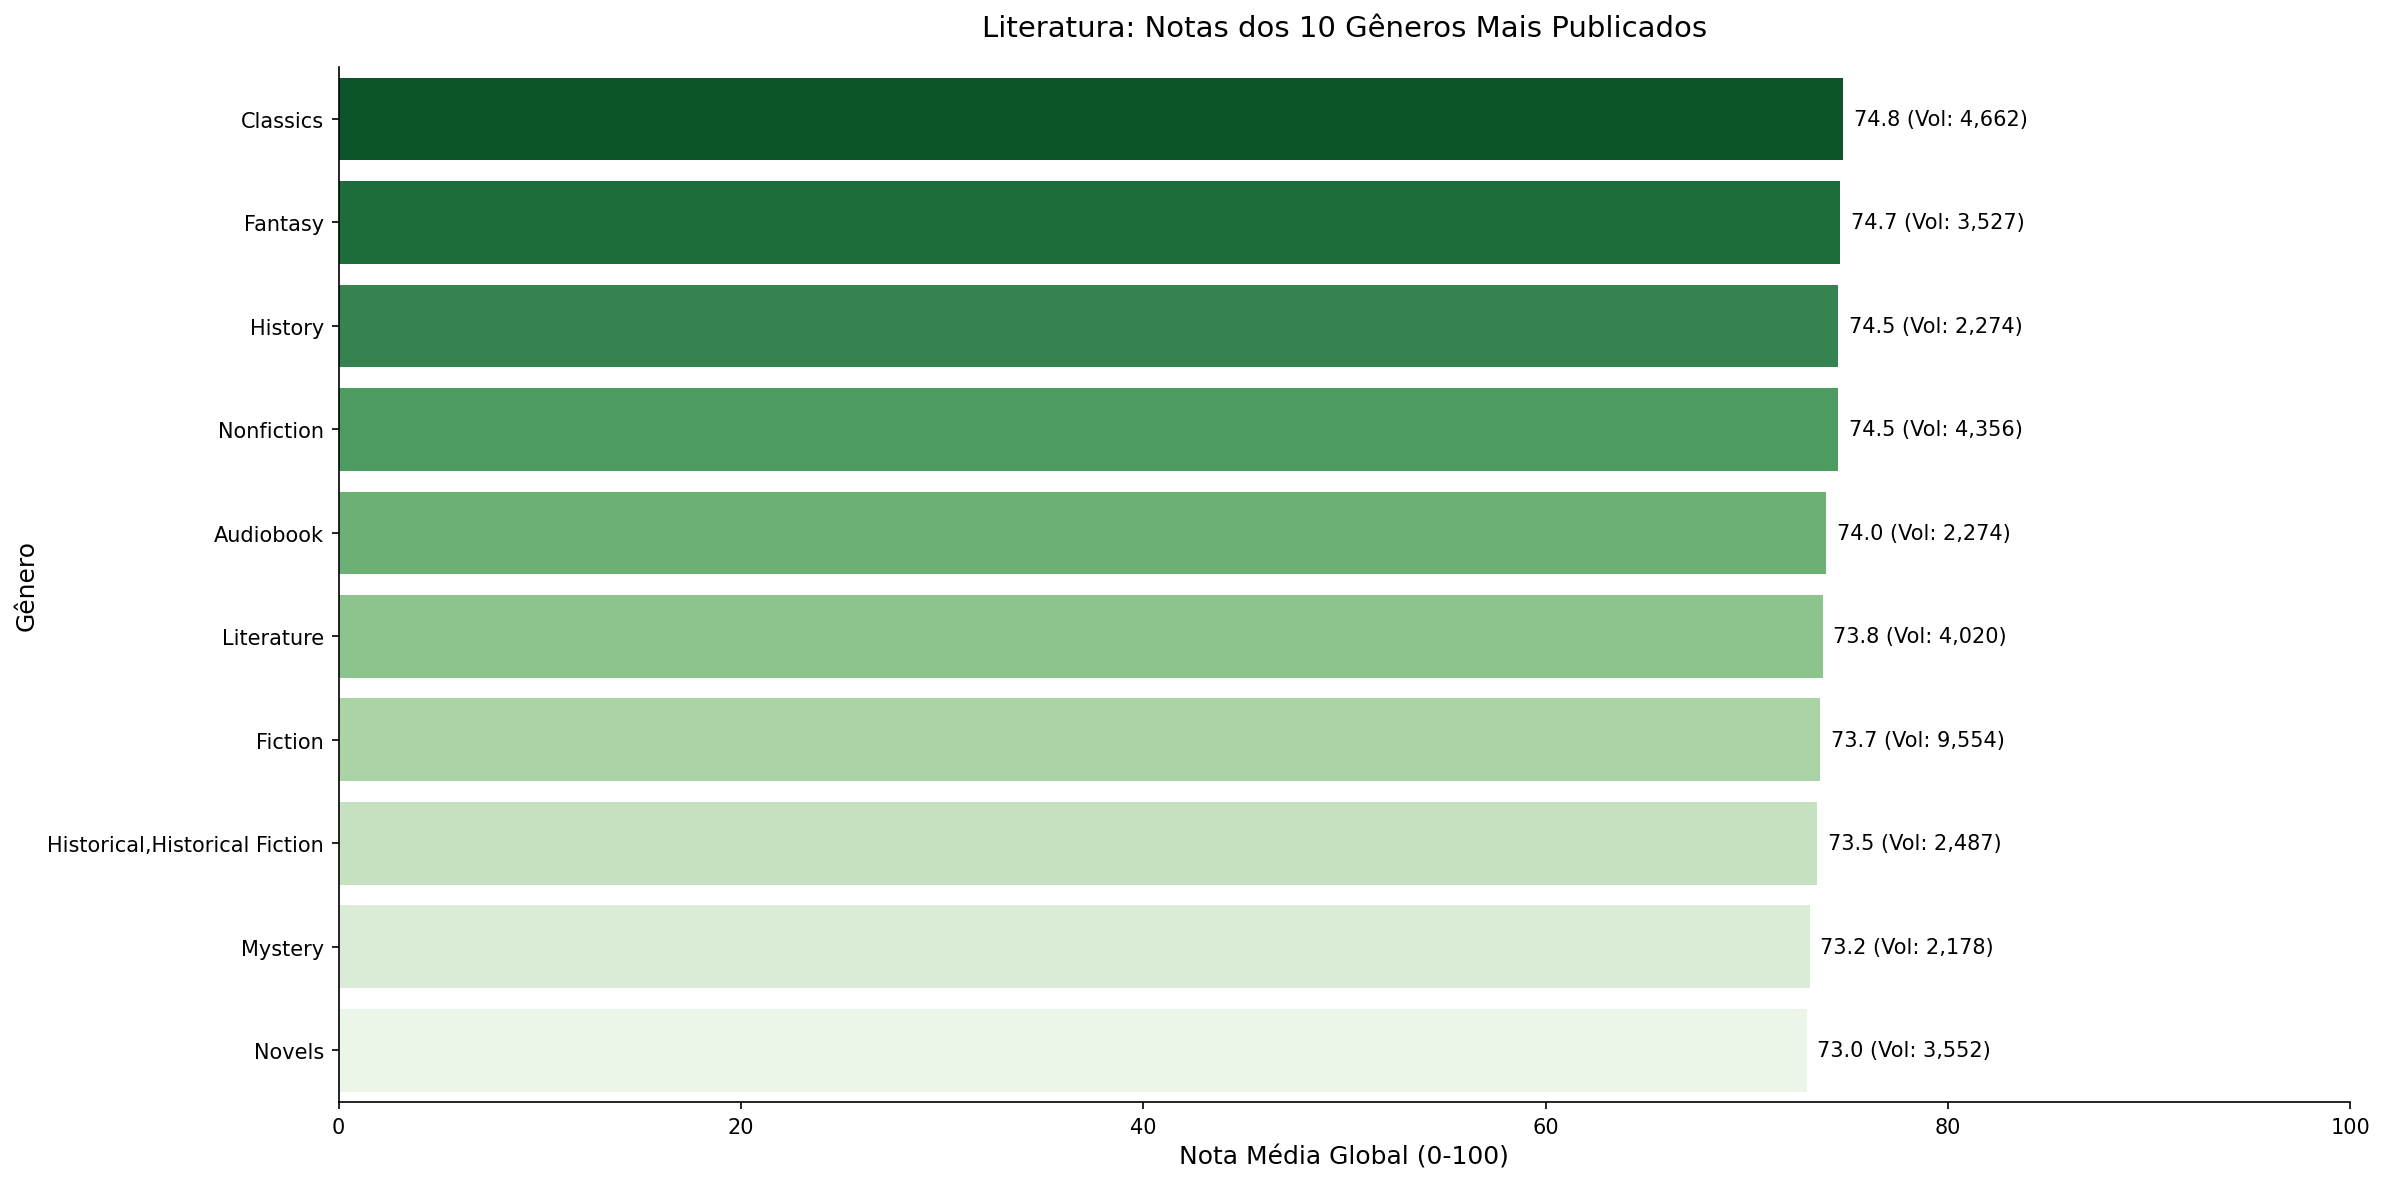

In [21]:
for i in (0,1):
    grafico_nota_media_genero(
        df=df_bolha_desc[
            df_bolha_desc['media_type'] == midia[i]
        ]
        .head(10)
        .sort_values('Nota_Media_Genero', ascending=False), 
        palette=cor[i],
        titulo=tipo_titulo('Mais', midia[i])
    )

#### Análise do Menor Volume de Obras

In [15]:
# Notas Por Gêneros Com Menor Volume de Obras
df_bolha_asc = df_genre_dynamics.sort_values('volume_obras', ascending=True)

favoritismo_por_volume(df_bolha_asc)

,media_type,genres,volume_obras,Nota_Media_Genero
74,Movie,TV Movie,713,58.06
73,Movie,Western,1039,59.73
70,Movie,Gênero Não Identificado,1399,60.96
60,Movie,War,1410,64.75
58,Movie,History,1485,66.00
59,Movie,Music,1612,65.11
68,Movie,Foreign,1634,61.68
57,Movie,Animation,2061,66.22
67,Movie,Fantasy,2543,61.75
64,Movie,Mystery,2692,62.03


,media_type,genres,volume_obras,Nota_Media_Genero
16,Book,"Mystery,Detective",519,74.68
2,Book,Spirituality,529,75.45
24,Book,"Literature,19th Century",548,74.43
30,Book,"Fantasy,Paranormal",577,73.94
27,Book,"Humor,Comedy",590,74.19
55,Book,"Womens Fiction,Chick Lit",612,70.84
14,Book,"Fantasy,Magic",617,74.72
51,Book,Gênero Não Identificado,649,72.49
15,Book,War,658,74.69
18,Book,"Writing,Essays",679,74.59


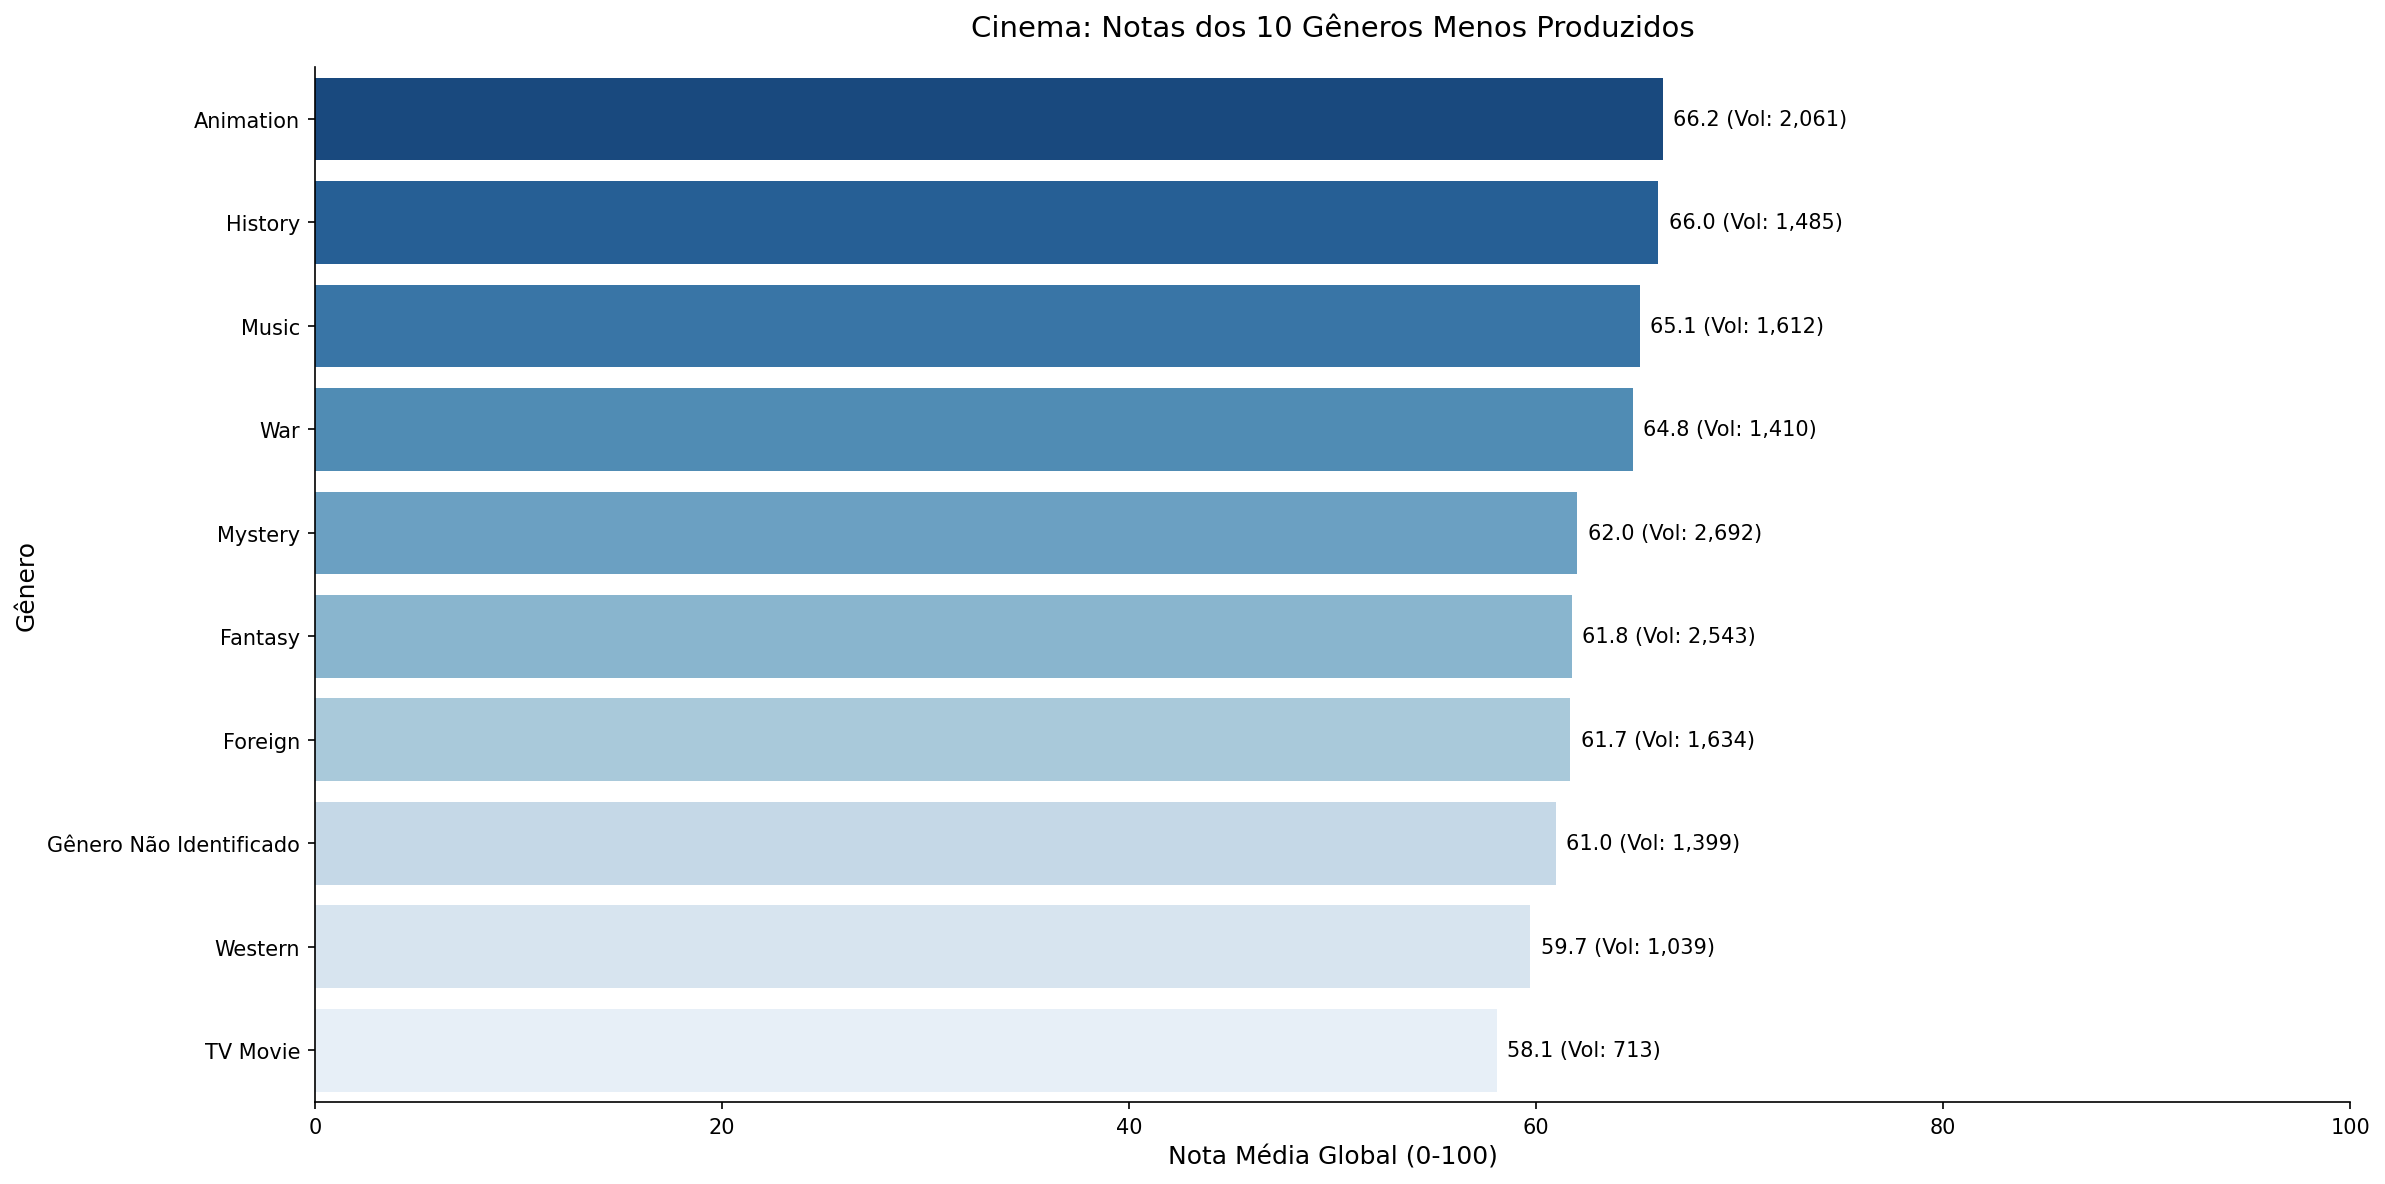

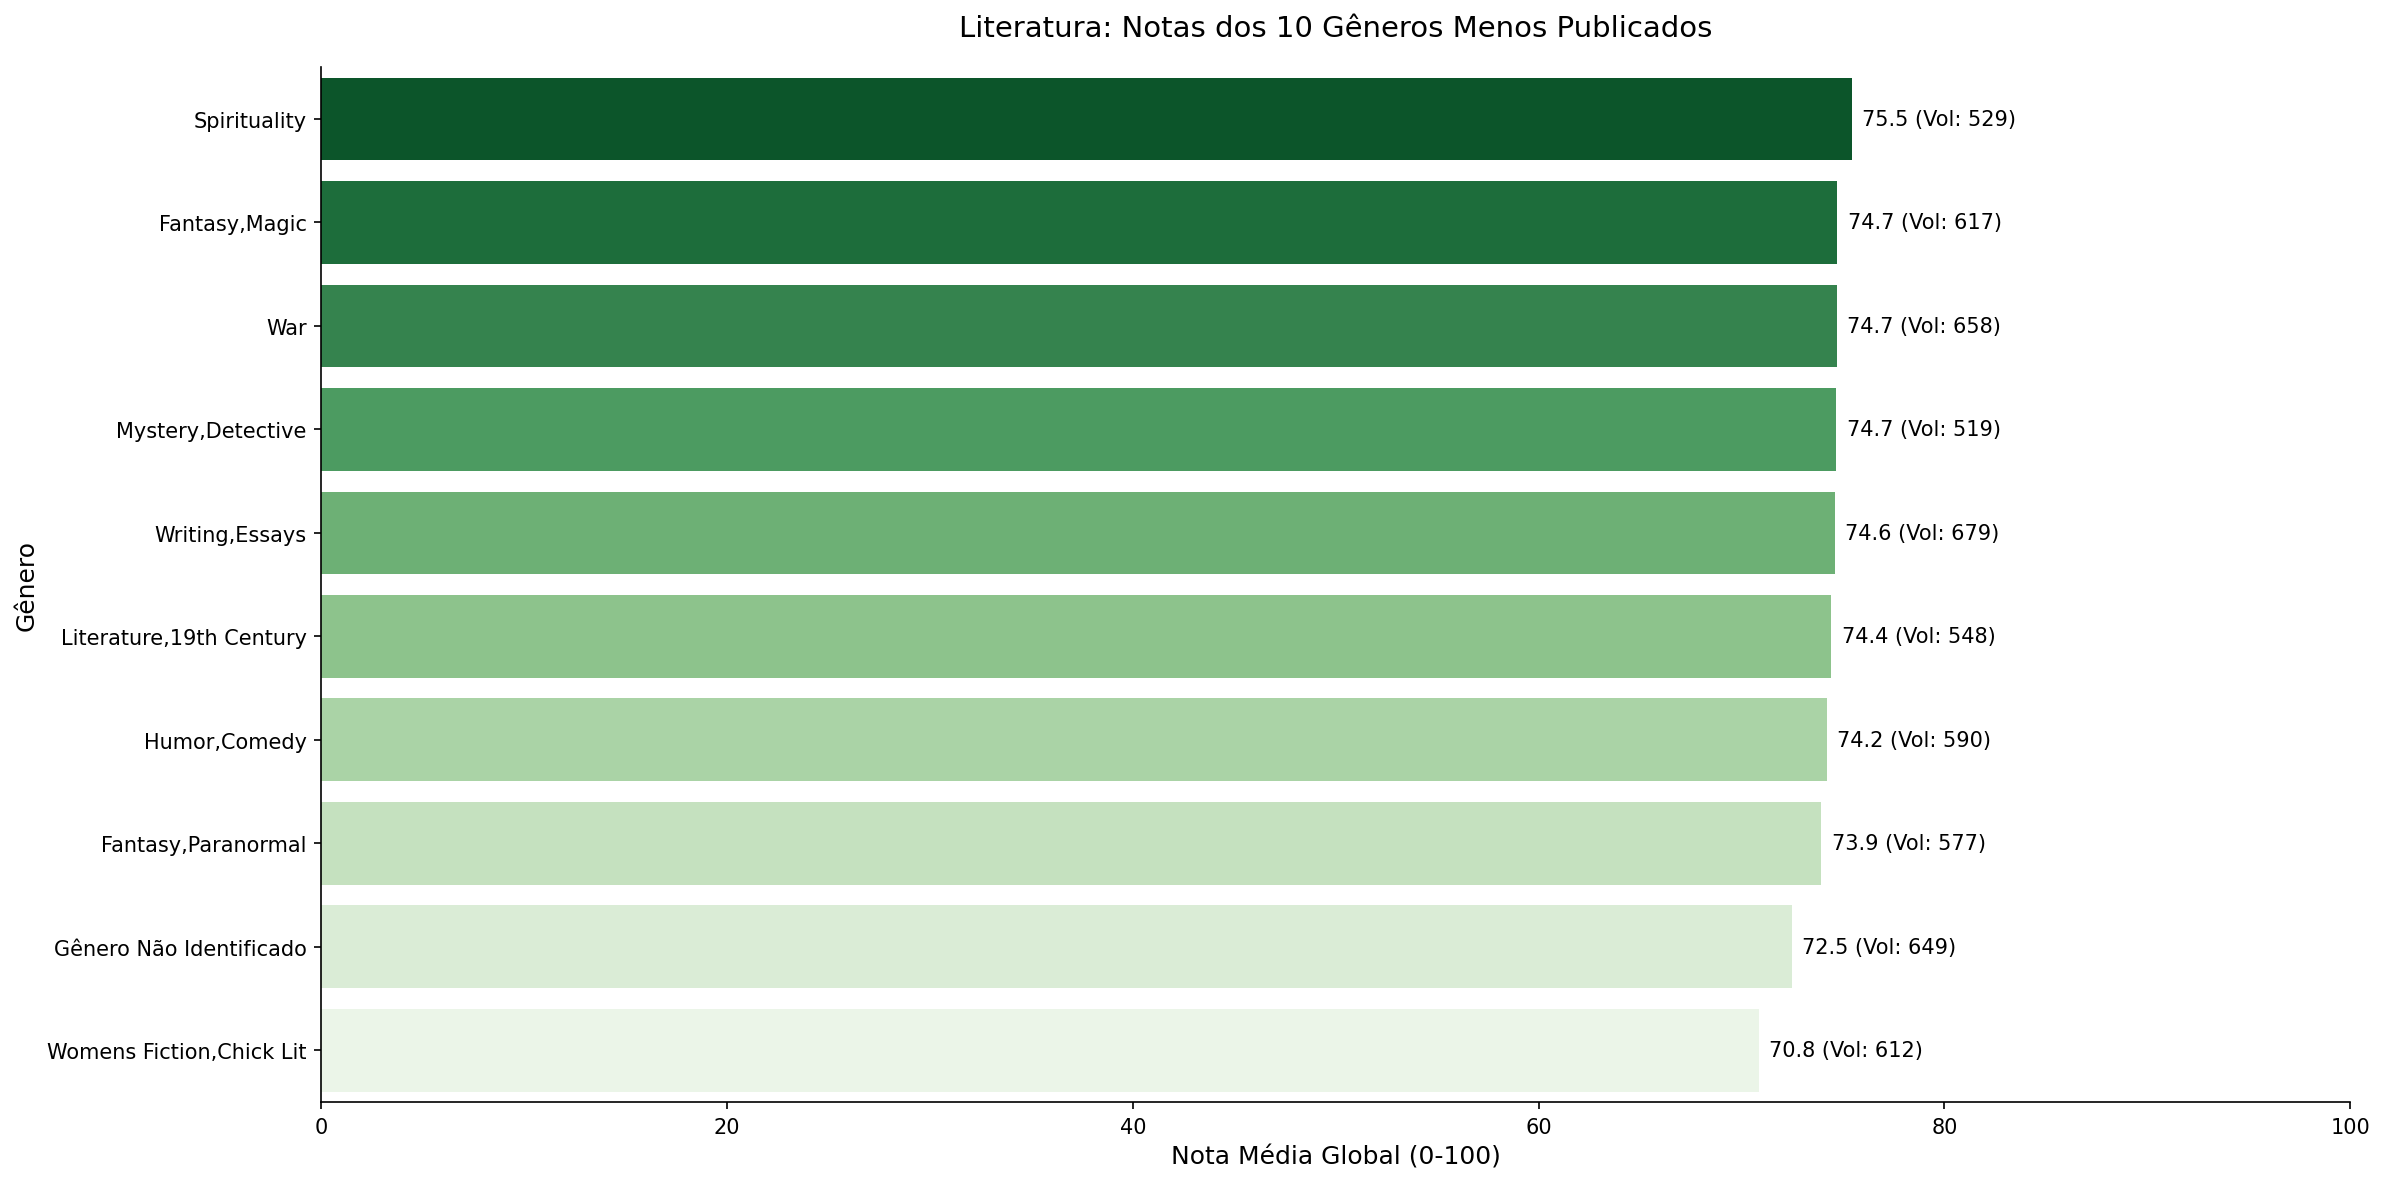

In [16]:
for i in (0,1):
    grafico_nota_media_genero(
        df=df_bolha_asc[
            df_bolha_asc['media_type'] == midia[i]
        ]
        .head(10)
        .sort_values('Nota_Media_Genero', ascending=False),
        palette=cor[i],
        titulo=tipo_titulo('Menos', midia[i])
    )

#### SCATTER PLOT

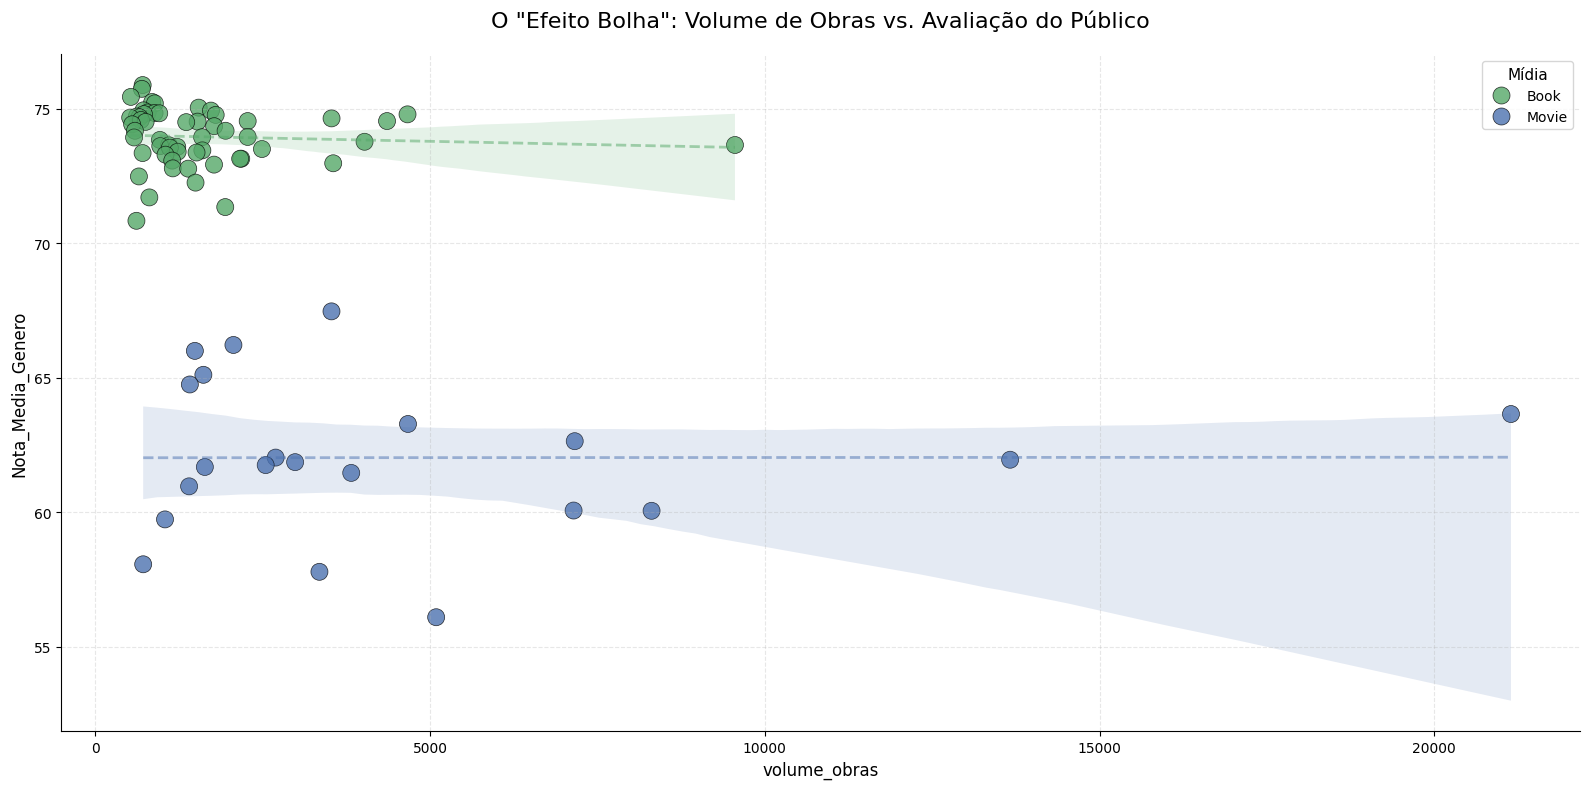

In [17]:
plt.figure(figsize=(16, 8))

# Gráfico de dispersão principal
sns.scatterplot(
    data=df_genre_dynamics, 
    x='volume_obras', 
    y='Nota_Media_Genero', 
    hue='media_type',
    palette={'Movie': '#4C72B0', 'Book': '#55A868'},
    s=150, 
    alpha=0.8, 
    edgecolor='black',
    linewidth=0.5
)

plt.title('O "Efeito Bolha": Volume de Obras vs. Avaliação do Público', fontsize=16, pad=20)
plt.xlabel('Volume de Obras no Gênero (Tamanho do Mercado)', fontsize=12)
plt.ylabel('Nota Média do Gênero Global (0-100)', fontsize=12)

# Linhas de tendência (regressão linear) para cada indústria
sns.regplot(
    data=df_genre_dynamics[df_genre_dynamics['media_type'] == 'Movie'], 
    x='volume_obras', 
    y='Nota_Media_Genero', 
    scatter=False, 
    color='#4C72B0', 
    line_kws={"linestyle": "--", "alpha": 0.5, "linewidth": 2}
)

sns.regplot(
    data=df_genre_dynamics[df_genre_dynamics['media_type'] == 'Book'], 
    x='volume_obras', 
    y='Nota_Media_Genero', 
    scatter=False, 
    color='#55A868', 
    line_kws={"linestyle": "--", "alpha": 0.5, "linewidth": 2}
)

plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()

plt.legend(title='Mídia', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.show()

### Salvando Nova Tabela 

In [18]:
dbc.save_db(
    df=df_genre_dynamics,
    pasta='../../data/processed',
    nome_banco='unified_media_catalog',
    nome_tabela='unified_media_volume_score_genres'
)

# Para uso no Power BI
df_genre_dynamics.to_excel(
    '../../data/powerbi_export/unified_media_volume_score_genres.xlsx', 
    index=False
)


Sucesso! Tabela 'unified_media_volume_score_genres' criada no banco: 'unified_media_catalog.db'


---
## Conclusões: Dinâmicas de Género e o Mercado Narrativo

**1. O Paradoxo do Volume vs. Avaliação (O "Efeito Bolha")**

* **A Descoberta:** O cinema sofre de uma clara penalização qualitativa no mercado *mainstream* (reta de tendência descendente). Em contrapartida, a literatura mantém a sua perceção de qualidade inabalável, independentemente da escala de produção do género (reta de tendência horizontal).
  
* **O Racional de Negócio:** Géneros cinematográficos de massas (como Comédia ou Ação) são estrategicamente desenhados para atrair um público generalista. Ao tentarem "agradar a todos", atraem inevitavelmente um maior escrutínio crítico. Por outro lado, géneros de nicho no cinema (ex: Documentários) atraem um público já convertido e apaixonado pelo tema, inflacionando a nota média (o verdadeiro Efeito Bolha). Na literatura, este efeito é mitigado por uma forte segmentação natural: os leitores auto-filtram o seu consumo. O leitor de Fantasia consome ativamente Fantasia, criando "nichos massivos" extremamente leais que não sofrem a mesma penalização que os *blockbusters* de Hollywood.

**2. A Assimetria Estrutural (Folksonomia vs. Taxonomia)**

* **A Descoberta:** A forma como a indústria cataloga as suas histórias diverge brutalmente. O "Drama" representa cerca de 22% de todo o cinema, mas apenas ~0.5% da literatura isolada. Em simultâneo, a Fantasia é o grande território comum, apresentando um equilíbrio perfeito de ~2.6% em ambas as indústrias.
  
* **O Racional de Negócio:** Plataformas de cinema (como o TMDB) impõem uma *Taxonomia* estrita (um menu fechado de categorias clássicas). Plataformas literárias colaborativas (como o Goodreads) operam por *Folksonomia* (etiquetas orgânicas geradas pelo comportamento do consumidor). Esta diferença estrutural dilui os géneros tradicionais literários em centenas de sub-nichos específicos e revela o peso gigantesco de categorias pragmáticas que o cinema ignora (como *Nonfiction*, *Classics* e *Reference*).

**3. O Risco de Entretenimento (O Caso do Terror)**

* **A Descoberta:** O Terror (Horror) é um dos géneros mais prolíficos da indústria cinematográfica (ocupando o Top 6 em volume absoluto), mas apresenta sistematicamente as notas médias mais baixas de todo o mercado (abaixo de 60/100).
  
* **O Racional de Negócio:** O Terror é estatisticamente altamente rentável e apresenta custos de produção notoriamente baixos, representando um risco financeiro mínimo para os estúdios. No entanto, é o género mais polarizador em termos de receção pública. A indústria continua a injetar um volume tremendo neste mercado não porque é criticamente aclamado, mas porque o seu modelo de negócio assimétrico é quase imune às críticas do público.